In [1]:
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [2]:
import collections
import math

def init_seq2seq_weights(module):
    if type(module) == nn.Linear:
        nn.init.xavier_uniform_(module.weight)
    if type(module) == nn.GRU:
        for param in module._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(module._parameters[param])

class Seq2SeqEncoder(d2l.Encoder):
    def __init__(self, vocab_size, embed_size, num_hidden, num_layers, dropout=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = d2l.GRU(embed_size, num_hidden, num_layers, dropout)
        self.apply(init_seq2seq_weights)

    def forward(self, X, *args):
        embs = self.embedding(X.t().type(torch.int64))
        outputs, state = self.rnn(embs)
        return outputs, state

In [3]:
class Seq2SeqDecoder(d2l.Decoder):
    """The RNN decoder for sequence to sequence learning."""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = d2l.GRU(embed_size+num_hiddens, num_hiddens,
                           num_layers, dropout)
        self.dense = nn.LazyLinear(vocab_size)
        self.apply(init_seq2seq_weights)

    def init_state(self, enc_all_outputs, *args):
        return enc_all_outputs

    def forward(self, X, state):
        # X shape: (batch_size, num_steps)
        # embs shape: (num_steps, batch_size, embed_size)
        embs = self.embedding(X.t().type(torch.int32))
        enc_output, hidden_state = state
        # context shape: (batch_size, num_hiddens)
        context = enc_output[-1]
        # Broadcast context to (num_steps, batch_size, num_hiddens)
        context = context.repeat(embs.shape[0], 1, 1)
        # Concat at the feature dimension
        embs_and_context = torch.cat((embs, context), -1)
        outputs, hidden_state = self.rnn(embs_and_context, hidden_state)
        outputs = self.dense(outputs).swapaxes(0, 1)
        # outputs shape: (batch_size, num_steps, vocab_size)
        # hidden_state shape: (num_layers, batch_size, num_hiddens)
        return outputs, [enc_output, hidden_state]


In [4]:
class Seq2Seq(d2l.EncoderDecoder):  #@save
    """The RNN encoder--decoder for sequence to sequence learning."""
    def __init__(self, encoder, decoder, tgt_pad, lr):
        super().__init__(encoder, decoder)
        self.save_hyperparameters()

    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)

    def configure_optimizers(self):
        # Adam optimizer is used here
        return torch.optim.Adam(self.parameters(), lr=self.lr)


In [5]:
@d2l.add_to_class(Seq2Seq)
def loss(self, Y_hat, Y):
    l = super(Seq2Seq, self).loss(Y_hat, Y, averaged=False)
    mask = (Y.reshape(-1) != self.tgt_pad).type(torch.float32)
    return (l * mask).sum() / mask.sum()


In [6]:
@d2l.add_to_class(d2l.EncoderDecoder)  #@save
def predict_step(self, batch, device, num_steps,
                 save_attention_weights=False):
    batch = [a.to(device) for a in batch]
    src, tgt, src_valid_len, _ = batch
    enc_all_outputs = self.encoder(src, src_valid_len)
    dec_state = self.decoder.init_state(enc_all_outputs, src_valid_len)
    outputs, attention_weights = [tgt[:, (0)].unsqueeze(1), ], []
    for _ in range(num_steps):
        Y, dec_state = self.decoder(outputs[-1], dec_state)
        outputs.append(Y.argmax(2))
        # Save attention weights (to be covered later)
        if save_attention_weights:
            attention_weights.append(self.decoder.attention_weights)
    return torch.cat(outputs[1:], 1), attention_weights


In [7]:
def bleu(pred_seq, label_seq, k):  #@save
    """Compute the BLEU."""
    pred_tokens, label_tokens = pred_seq.split(' '), label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    score = math.exp(min(0, 1 - len_label / len_pred))
    for n in range(1, min(k, len_pred) + 1):
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i: i + n])] += 1
        for i in range(len_pred - n + 1):
            if label_subs[' '.join(pred_tokens[i: i + n])] > 0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i: i + n])] -= 1
        score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    return score


In [8]:
engs = [
    'go .', 'i lost .', 'he\'s calm .', 'i\'m home .', 
    'she likes coffee .', 'they are reading books .', 'we are running .',
    'where is the library ?', 'the weather is nice today .',
    'he enjoys playing soccer .', 'i will call you later .',
    'do you like music ?', 'my favorite color is blue .',
    'i don\'t understand .', 'please help me .', 'what time is it ?',
    'this is my brother .', 'we love traveling .', 'he went to school .',
    'she speaks three languages .'
]

fras = [
    'va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .',
    'elle aime le café .', 'ils lisent des livres .', 'nous courons .',
    'où est la bibliothèque ?', 'il fait beau aujourd\'hui .',
    'il aime jouer au football .', 'je t\'appellerai plus tard .',
    'aimes-tu la musique ?', 'ma couleur préférée est le bleu .',
    'je ne comprends pas .', 'aidez-moi s\'il vous plaît .', 'quelle heure est-il ?',
    'c\'est mon frère .', 'nous aimons voyager .', 'il est allé à l\'école .',
    'elle parle trois langues .'
]


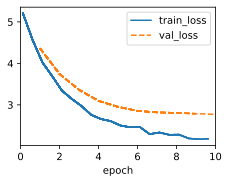

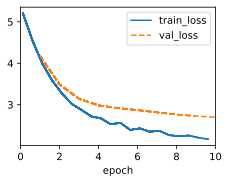

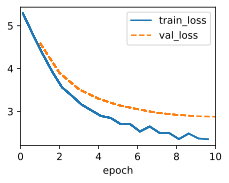

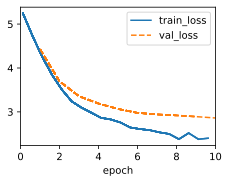

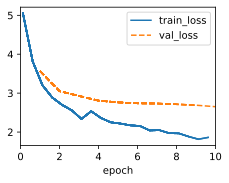

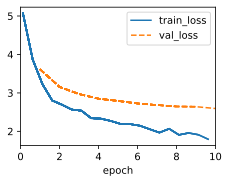

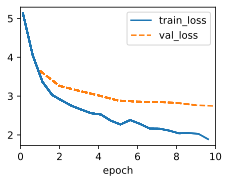

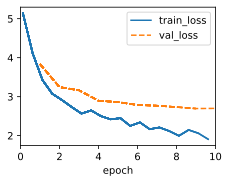

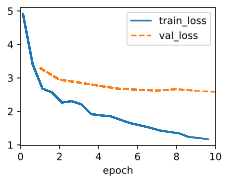

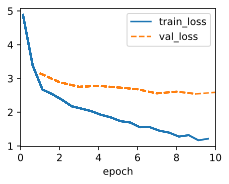

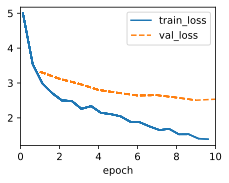

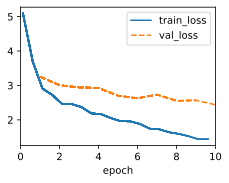

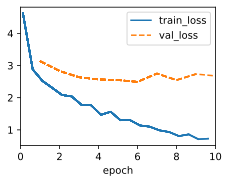

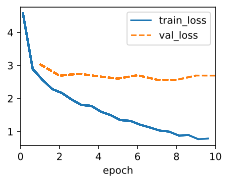

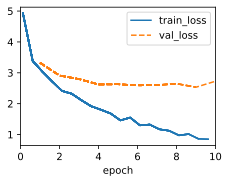

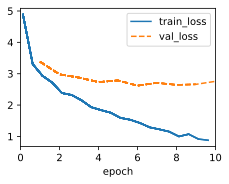

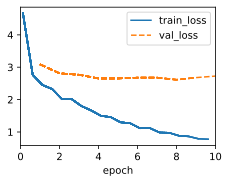

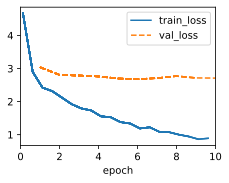

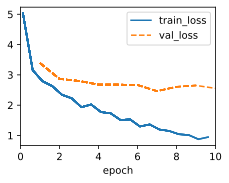

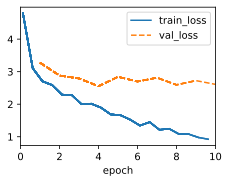

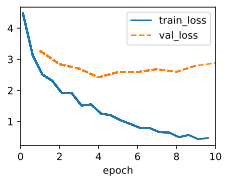

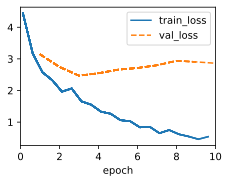

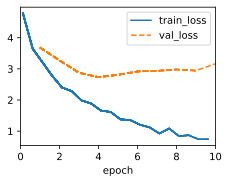

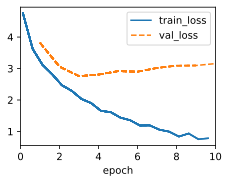

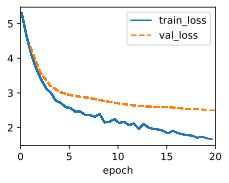

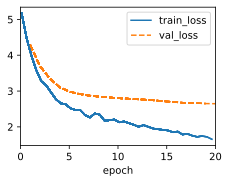

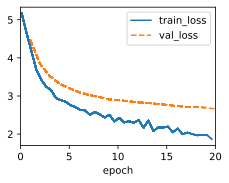

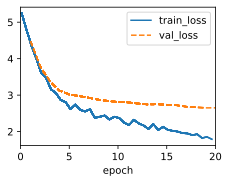

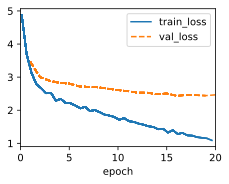

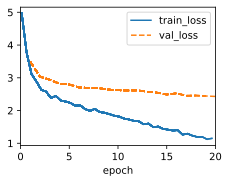

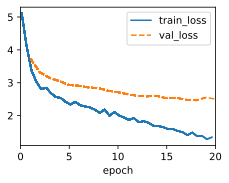

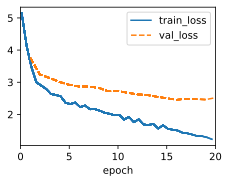

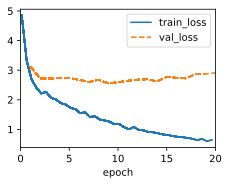

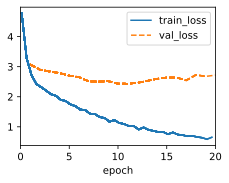

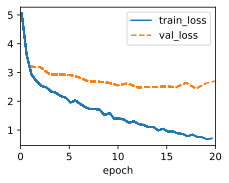

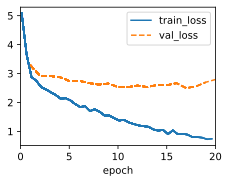

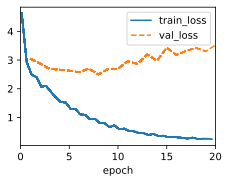

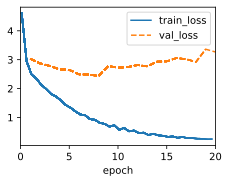

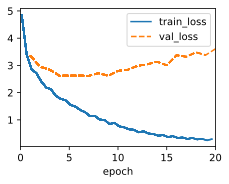

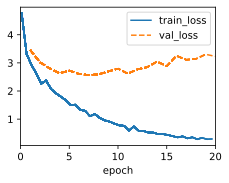

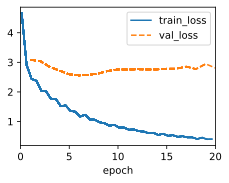

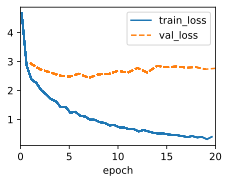

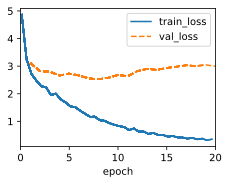

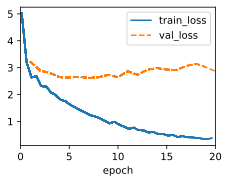

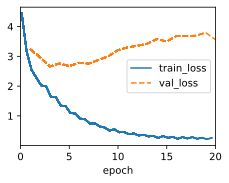

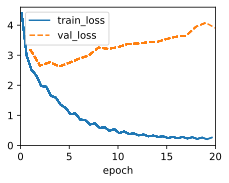

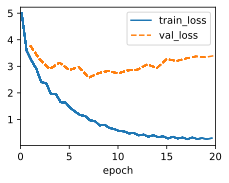

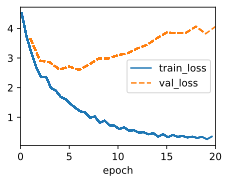

In [ ]:
"""Hyperparameter tuning"""
import time
learning_rates = [0.001, 0.005, 0.01]
hidden_units = [128, 256]
num_layers_options = [1, 2]
dropout_rates = [0.1, 0.2]
epochs = [10, 20]

results = []
for epoch in epochs:
    for lr in learning_rates:
        for num_hiddens in hidden_units:
            for num_layers in num_layers_options:
                for dropout in dropout_rates:
                    data = d2l.MTFraEng(batch_size=128)
                    embed_size = 256
                    encoder = Seq2SeqEncoder(
                        len(data.src_vocab), embed_size, num_hiddens, num_layers, dropout)
                    decoder = Seq2SeqDecoder(
                        len(data.tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
                    model = Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                                    lr=lr)
                    trainer = d2l.Trainer(max_epochs=epoch, gradient_clip_val=1, num_gpus=1)
                    
                    start_time = time.time()
                    trainer.fit(model, data)
                    end_time = time.time()

                    elapsed_time = end_time - start_time
                    results.append((epoch, lr, num_hiddens, num_layers, dropout, elapsed_time))


In [12]:
for epoch, lr, num_hiddens, num_layers, dropout, elapsed_time in results:
    print(f"Epoch: {epoch}, LR: {lr}, Hidden Units: {num_hiddens}, Layers: {num_layers}, Dropout: {dropout}, Time: {elapsed_time:.2f} seconds")

Epoch: 10, LR: 0.001, Hidden Units: 128, Layers: 1, Dropout: 0.1, Time: 2.08 seconds
Epoch: 10, LR: 0.001, Hidden Units: 128, Layers: 1, Dropout: 0.2, Time: 2.09 seconds
Epoch: 10, LR: 0.001, Hidden Units: 128, Layers: 2, Dropout: 0.1, Time: 2.11 seconds
Epoch: 10, LR: 0.001, Hidden Units: 128, Layers: 2, Dropout: 0.2, Time: 2.13 seconds
Epoch: 10, LR: 0.001, Hidden Units: 256, Layers: 1, Dropout: 0.1, Time: 2.31 seconds
Epoch: 10, LR: 0.001, Hidden Units: 256, Layers: 1, Dropout: 0.2, Time: 2.07 seconds
Epoch: 10, LR: 0.001, Hidden Units: 256, Layers: 2, Dropout: 0.1, Time: 2.13 seconds
Epoch: 10, LR: 0.001, Hidden Units: 256, Layers: 2, Dropout: 0.2, Time: 2.14 seconds
Epoch: 10, LR: 0.005, Hidden Units: 128, Layers: 1, Dropout: 0.1, Time: 2.07 seconds
Epoch: 10, LR: 0.005, Hidden Units: 128, Layers: 1, Dropout: 0.2, Time: 2.20 seconds
Epoch: 10, LR: 0.005, Hidden Units: 128, Layers: 2, Dropout: 0.1, Time: 2.06 seconds
Epoch: 10, LR: 0.005, Hidden Units: 128, Layers: 2, Dropout: 0.2,

go . => ['<unk>', '!'], bleu,0.000
i lost . => ['je', 'suis', '<unk>', '.'], bleu,0.000
he's calm . => ['je', 'suis', '<unk>', '.'], bleu,0.000
i'm home . => ['je', 'suis', '<unk>', '.'], bleu,0.512
she likes coffee . => ['je', 'suis', '<unk>', '.'], bleu,0.000
they are reading books . => ['<unk>', '.'], bleu,0.000
we are running . => ['<unk>', '.'], bleu,0.000
where is the library ? => ['<unk>', '?'], bleu,0.000
the weather is nice today . => ['<unk>', '!'], bleu,0.000
he enjoys playing soccer . => ['je', 'suis', '<unk>', '.'], bleu,0.000
i will call you later . => ['<unk>', '.'], bleu,0.000
do you like music ? => ['<unk>', '?'], bleu,0.000
my favorite color is blue . => ['<unk>', '.'], bleu,0.000
i don't understand . => ['je', '<unk>', '.'], bleu,0.000
please help me . => ['<unk>', '.'], bleu,0.000
what time is it ? => ['<unk>', '?'], bleu,0.000
this is my brother . => ['<unk>', '.'], bleu,0.000
we love traveling . => ['<unk>', '.'], bleu,0.000
he went to school . => ['je', 'suis', '

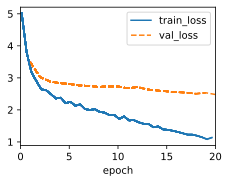

In [ ]:
data = d2l.MTFraEng(batch_size=128)
embed_size, num_hiddens, num_layers, dropout = 256, 256, 1, 0.2
encoder = Seq2SeqEncoder(
    len(data.src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqDecoder(
    len(data.tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
model = Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                lr=0.001)
trainer = d2l.Trainer(max_epochs=20, gradient_clip_val=1, num_gpus=1) 

trainer.fit(model, data)


preds, _ = model.predict_step(
    data.build(engs, fras), d2l.try_gpu(), data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{bleu(" ".join(translation), fr, k=2):.3f}')


In [38]:
class Seq2Seq(d2l.EncoderDecoder):  #@save
    """The RNN encoder--decoder for sequence to sequence learning."""
    def __init__(self, encoder, decoder, tgt_pad, lr):
        super().__init__(encoder, decoder)
        self.save_hyperparameters()

    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)

    def configure_optimizers(self):
        # Adam optimizer is used here
        return torch.optim.Adam(self.parameters(), lr=self.lr)
    
    def loss(self, Y_hat, Y):
        return super(Seq2Seq, self).loss(Y_hat, Y)


go . => ['<unk>', '!'], bleu,0.000
i lost . => ['je', 'suis', '<unk>', '.'], bleu,0.000
he's calm . => ['je', 'suis', '<unk>', '.'], bleu,0.000
i'm home . => ['je', 'suis', '<unk>', '.'], bleu,0.512
she likes coffee . => ['<unk>', '!'], bleu,0.000
they are reading books . => ['<unk>', '!'], bleu,0.000
we are running . => ['<unk>', '!'], bleu,0.000
where is the library ? => ['<unk>', '?'], bleu,0.000
the weather is nice today . => ['<unk>', '!'], bleu,0.000
he enjoys playing soccer . => ['<unk>', '!'], bleu,0.000
i will call you later . => ['<unk>', '!'], bleu,0.000
do you like music ? => ['<unk>', '?'], bleu,0.000
my favorite color is blue . => ['<unk>', '!'], bleu,0.000
i don't understand . => ['je', 'suis', '<unk>', '.'], bleu,0.000
please help me . => ['<unk>', '.'], bleu,0.000
what time is it ? => ['<unk>', '?'], bleu,0.000
this is my brother . => ['<unk>', '!'], bleu,0.000
we love traveling . => ['<unk>', '!'], bleu,0.000
he went to school . => ['<unk>', '!'], bleu,0.000
she speak

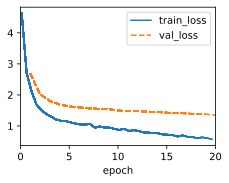

In [39]:
data = d2l.MTFraEng(batch_size=128)
embed_size, num_hiddens, num_layers, dropout = 256, 256, 1, 0.2
encoder = Seq2SeqEncoder(
    len(data.src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqDecoder(
    len(data.tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
model = Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                lr=0.001)
trainer = d2l.Trainer(max_epochs=20, gradient_clip_val=1, num_gpus=1)

trainer.fit(model, data)

preds, _ = model.predict_step(
    data.build(engs, fras), d2l.try_gpu(), data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{bleu(" ".join(translation), fr, k=2):.3f}')

In [40]:
class Seq2Seq(d2l.EncoderDecoder):  #@save
    """The RNN encoder--decoder for sequence to sequence learning."""
    def __init__(self, encoder, decoder, tgt_pad, lr):
        super().__init__(encoder, decoder)
        self.save_hyperparameters()

    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)

    def configure_optimizers(self):
        # Adam optimizer is used here
        return torch.optim.Adam(self.parameters(), lr=self.lr)
    
    def loss(self, Y_hat, Y):
        l = super(Seq2Seq, self).loss(Y_hat, Y, averaged=False)
        mask = (Y.reshape(-1) != self.tgt_pad).type(torch.float32)
        return (l * mask).sum() / mask.sum()

go . => ['<unk>', '!'], bleu,0.000
i lost . => ['je', 'suis', '<unk>', '.'], bleu,0.000
he's calm . => ['nous', '<unk>', '.'], bleu,0.000
i'm home . => ['je', 'suis', '<unk>', '.'], bleu,0.512
she likes coffee . => ['<unk>', '.'], bleu,0.000
they are reading books . => ['<unk>', '.'], bleu,0.000
we are running . => ['<unk>', '.'], bleu,0.000
where is the library ? => ['<unk>', '?'], bleu,0.000
the weather is nice today . => ['<unk>', '!'], bleu,0.000
he enjoys playing soccer . => ['<unk>', '!'], bleu,0.000
i will call you later . => ['<unk>', '!'], bleu,0.000
do you like music ? => ['<unk>', '<unk>', '?'], bleu,0.000
my favorite color is blue . => ['<unk>', '.'], bleu,0.000
i don't understand . => ['je', '<unk>', '.'], bleu,0.000
please help me . => ['<unk>', '.'], bleu,0.000
what time is it ? => ['<unk>', '?'], bleu,0.000
this is my brother . => ['<unk>', '.'], bleu,0.000
we love traveling . => ['<unk>', '.'], bleu,0.000
he went to school . => ['<unk>', '.'], bleu,0.000
she speaks thr

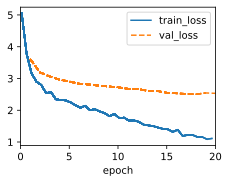

In [41]:
data = d2l.MTFraEng(batch_size=128)
embed_size, num_hiddens, num_layers, dropout = 256, 256, 1, 0.2
encoder = Seq2SeqEncoder(
    len(data.src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqDecoder(
    len(data.tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
model = Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                lr=0.001)
trainer = d2l.Trainer(max_epochs=20, gradient_clip_val=1, num_gpus=1)

trainer.fit(model, data)

preds, _ = model.predict_step(
    data.build(engs, fras), d2l.try_gpu(), data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{bleu(" ".join(translation), fr, k=2):.3f}')

go . => ['va', '!'], bleu,1.000
i lost . => ["j'ai", 'perdu', '.'], bleu,1.000
he's calm . => ['elle', 'est', '<unk>', '.'], bleu,0.000
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu,1.000
she likes coffee . => ['elle', '<unk>', '.'], bleu,0.000
they are reading books . => ['sois', 'gentil', '.'], bleu,0.000
we are running . => ['nous', '<unk>', '.'], bleu,0.000
where is the library ? => ['<unk>', '<unk>', '?'], bleu,0.000
the weather is nice today . => ['les', '<unk>', '<unk>', '.'], bleu,0.000
he enjoys playing soccer . => ['il', 'essaye', '.'], bleu,0.000
i will call you later . => ['je', 'suis', '<unk>', '.'], bleu,0.000
do you like music ? => ['<unk>', '?'], bleu,0.000
my favorite color is blue . => ['les', '<unk>', '<unk>', '.'], bleu,0.000
i don't understand . => ['je', '<unk>', '.'], bleu,0.000
please help me . => ['<unk>', '.'], bleu,0.000
what time is it ? => ['<unk>', 'capté', '?'], bleu,0.000
this is my brother . => ['<unk>', '!'], bleu,0.000
we love traveling . => 

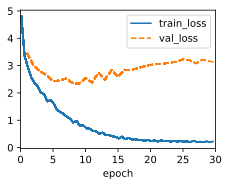

In [32]:
data = d2l.MTFraEng(batch_size=128)
embed_size, num_hiddens, num_layers, dropout = 256, 256, 2, 0.2
encoder = Seq2SeqEncoder(
    len(data.src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqDecoder(
    len(data.tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
model = Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                lr=0.005)
trainer = d2l.Trainer(max_epochs=30, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

preds, _ = model.predict_step(
    data.build(engs, fras), d2l.try_gpu(), data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{bleu(" ".join(translation), fr, k=2):.3f}')